## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : [Car Prices Dataset]

## Problem Statement

[its hard to know the right price of a used car because cars have many different features . The goal of this project is to build a Machine Learning model that predicts car prices based on these features.]

## Data Info
Data Source :https://www.kaggle.com/datasets/sidharth178/car-prices-dataset/data

## Data Dictionary
| Column | Type | Description |
| ------ | ---- | ----------- |
| ID | Integer | Unique identifier for each car entry |
| Price | Numerical | The market price of the car (Target Column) |
| Levy | Numerical / Text | Tax or duty amount imposed on the vehicle |
| Manufacturer | Categorical | The brand or maker of the car (e.g., Toyota, BMW) |
| Model | Categorical | The specific model name of the vehicle |
| Prod. year | Integer | The manufacturing year of the vehicle |
| Category | Categorical | The body style/type of the vehicle (e.g., SUV, Sedan) |
| Leather interior | Binary / Boolean | Indicates whether the car has a leather interior (Yes/No) |
| Fuel type | Categorical | The type of fuel used (e.g., Petrol, Diesel, Hybrid) |
| Engine volume | Numerical / Text | Engine capacity in liters (may include turbo info) |
| Mileage | Numerical / Text | Total distance driven by the car |
| Cylinders | Integer | Number of engine cylinders |
| Gear box type | Categorical | Transmission type (e.g., Automatic, Manual, Tiptronic) |
| Drive wheels | Categorical | Drivetrain configuration (e.g., Front, Rear, 4x4) |
| Doors | Categorical / Text | Number of doors on the vehicle |
| Wheel | Categorical | Steering wheel position (Left wheel / Right wheel) |
| Color | Categorical | Exterior color of the vehicle |
| Airbags | Integer | Total count of safety airbags in the car |

In [41]:
# start you EDA
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn import metrics
from sklearn.model_selection import KFold
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [42]:
df = pd.read_csv('./New folder/train.csv')
df.shape

(19237, 18)

In [43]:
df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

In [44]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [46]:
df.isna().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [47]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [48]:
df.duplicated().sum()

np.int64(313)

In [49]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [50]:
df['ID'].nunique()

18924

count    1.892400e+04
mean     1.858744e+04
std      1.921356e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.206300e+04
max      2.630750e+07
Name: Price, dtype: float64
0
0


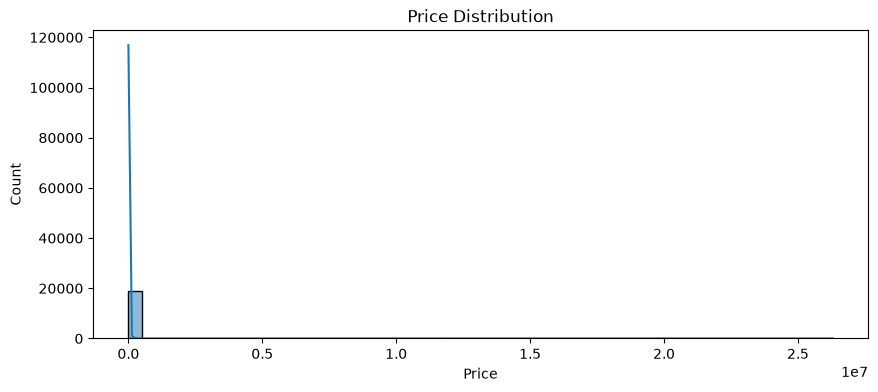

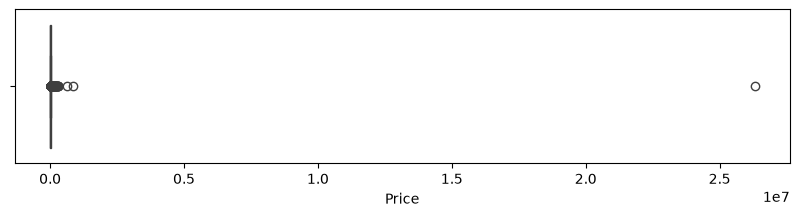

In [51]:

print(df['Price'].describe())

print((df['Price'] == 0).sum())
print((df['Price'] < 0).sum())

plt.figure(figsize=(10,4))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.show()

plt.figure(figsize=(10,2))
sns.boxplot(x=df['Price'])
plt.show()

In [52]:
# TOP 10
print(df['Price'].sort_values(ascending=False).head(10))

#  UNTOP 10 
print(df['Price'].sort_values(ascending=True).head(10))

print('Lenth:', len(df))
print('  less than 100:', (df['Price'] < 100).sum())
print('  more than 500000:', (df['Price'] > 500000).sum())

16983    26307500
8541       872946
1225       627220
5008       308906
14839      297930
9367       297930
7749       288521
10759      260296
5840       254024
15283      250574
Name: Price, dtype: int64
16992    1
7815     1
14642    3
15347    3
753      3
10885    3
9730     3
221      3
4776     3
14492    3
Name: Price, dtype: int64
Lenth: 18924
  less than 100: 349
  more than 500000: 3


In [53]:
lower_bound = 100  
upper_bound = 500000  

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

len(df)

18572

count     18572.000000
mean      17441.552714
std       18288.948720
min         100.000000
25%        5893.000000
50%       13485.000000
75%       22580.000000
max      308906.000000
Name: Price, dtype: float64


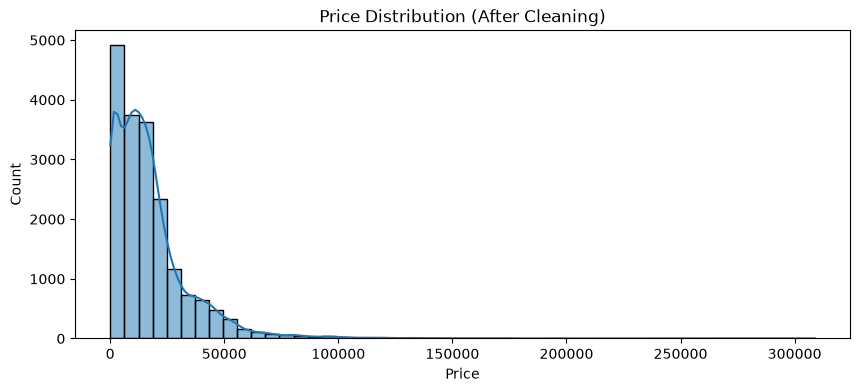

Skewness الجديد: 3.505079434645691


In [54]:
print(df['Price'].describe())

plt.figure(figsize=(10,4))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price Distribution (After Cleaning)')
plt.show()

print('Skewness :', df['Price'].skew())

In [55]:
df['Price_log'] = np.log1p(df['Price'])

count    18572.000000
mean         9.128553
std          1.413257
min          4.615121
25%          8.681690
50%          9.509407
75%         10.024864
max         12.640796
Name: Price_log, dtype: float64


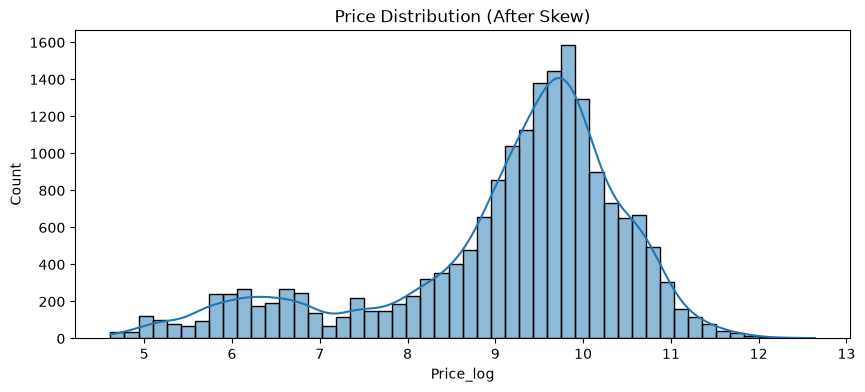

Skewness : 3.505079434645691


In [56]:
print(df['Price_log'].describe())

plt.figure(figsize=(10,4))
sns.histplot(df['Price_log'], bins=50, kde=True)
plt.title('Price Distribution (After Skew)')
plt.show()

print('Skewness :', df['Price'].skew())

In [62]:
len(df[df['Levy'] == '-'])

5431

In [59]:
print(df['Levy'].dtype)
print(df['Levy'].unique()[:20])
print(df['Levy'].value_counts().head(10))

str
<ArrowStringArray>
['1399', '1018',    '-',  '862',  '446',  '891',  '761',  '751',  '394',
 '1053', '1055', '1079',  '810', '2386', '1850',  '531',  '586', '1249',
 '2455',  '583']
Length: 20, dtype: str
Levy
-       5431
765      481
891      453
639      402
640      398
781      294
1017     278
707      268
836      259
642      258
Name: count, dtype: int64


In [63]:
df['Levy'] = df['Levy'].replace('-', np.nan)
df['Levy'] = df['Levy'].astype(float)

print(df['Levy'].dtype)
print(df['Levy'].isnull().sum())
print(df['Levy'].describe())

float64
5431
count    13141.000000
mean       906.472567
std        463.581988
min         87.000000
25%        640.000000
50%        781.000000
75%       1058.000000
max      11714.000000
Name: Levy, dtype: float64


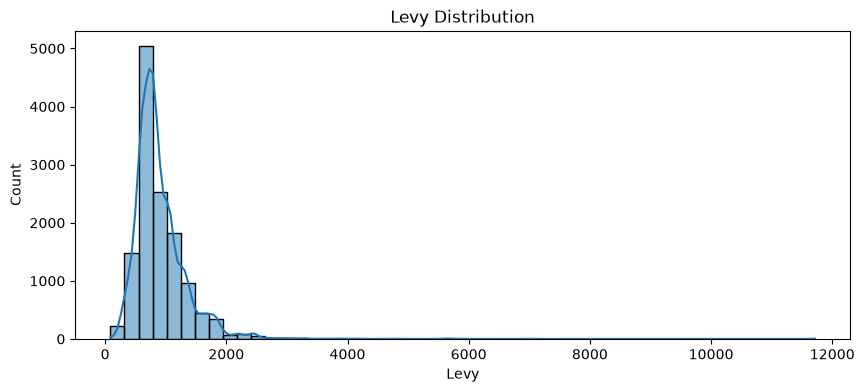

In [64]:
plt.figure(figsize=(10,4))
sns.histplot(df['Levy'].dropna(), bins=50, kde=True)
plt.title('Levy Distribution')
plt.show()

# Topic 2 : [Bank Marketing]

## Problem Statement

[Making phone calls to all customers for marketing takes a lot of time and costs money, but many customers say no. The goal of this project is to build a machine learning model that predicts if a customer will subscribe to a bank term deposit (yes or no). By predicting who is likely to join, the bank can focus only on interested clients and save time and money]

## Data Info
Data Source :https://archive-beta.ics.uci.edu/dataset/222/bank+marketing



## Data Dictionary
| Column | Type | Description |
| ------ | ---- | ----------- |
| age | int | Age of the client |
| job | object | Type of job (e.g., admin., blue-collar, entrepreneur, technician) |
| marital | object | Marital status (married, single, divorced) |
| education | object | Education level (primary, secondary, tertiary, unknown) |
| default | object | Has credit in default? (yes, no) |
| balance | int | Average yearly balance in euros |
| housing | object | Has a housing loan? (yes, no) |
| loan | object | Has a personal loan? (yes, no) |
| contact | object | Contact communication type (unknown, telephone, cellular) |
| day | int | Last contact day of the month |
| month | object | Last contact month of year (jan, feb, mar, ..., dec) |
| duration | int | Last contact duration in seconds |
| campaign | int | Number of contacts performed during this campaign for this client |
| pdays | int | Number of days after the client was last contacted from a previous campaign (-1 means not previously contacted) |
| previous | int | Number of contacts performed before this campaign for this client |
| poutcome | object | Outcome of the previous marketing campaign (unknown, other, failure, success) |
| y | object | Target variable: Has the client subscribed to a term deposit? (yes, no) |

In [8]:
df2 = pd.read_csv('./New folder/bank-full.csv', sep=';')
df2.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
df2.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [ ]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?

# Topic 3 : [Default of Credit Card Clients]

## Problem Statement

[When credit card clients default on their payments, banks lose a lot of money and face financial risk. The goal of this project is to build a machine learning model to predict whether a client will default on their credit card payment next month based on their demographic features and payment history. Predicting defaults helps banks reduce financial risk and manage credit better.]

## Data Info
Data Source :https://archive-beta.ics.uci.edu/dataset/350/default+of+credit+card+clients

## Data Dictionary
| Column | Type | Description |
| ------ | ---- | ----------- |
| LIMIT_BAL | float | Amount of given credit in NT dollars (includes individual and family/supplementary credit) |
| SEX | int | Gender (1 = male, 2 = female) |
| EDUCATION | int | Education level (1 = graduate school, 2 = university, 3 = high school, 4 = others, 5/6 = unknown) |
| MARRIAGE | int | Marital status (1 = married, 2 = single, 3 = others) |
| AGE | int | Age in years |
| PAY_0 | int | Repayment status in September (-1 = pay duly, 1 = payment delay for one month, 2 = payment delay for two months, ..., 8 = payment delay for eight months, 9 = payment delay for nine months and above) |
| PAY_2 | int | Repayment status in August (scale same as PAY_0) |
| PAY_3 | int | Repayment status in July (scale same as PAY_0) |
| PAY_4 | int | Repayment status in June (scale same as PAY_0) |
| PAY_5 | int | Repayment status in May (scale same as PAY_0) |
| PAY_6 | int | Repayment status in April (scale same as PAY_0) |
| BILL_AMT1 | float | Amount of bill statement in September (NT dollar) |
| BILL_AMT2 | float | Amount of bill statement in August (NT dollar) |
| BILL_AMT3 | float | Amount of bill statement in July (NT dollar) |
| BILL_AMT4 | float | Amount of bill statement in June (NT dollar) |
| BILL_AMT5 | float | Amount of bill statement in May (NT dollar) |
| BILL_AMT6 | float | Amount of bill statement in April (NT dollar) |
| PAY_AMT1 | float | Amount of previous payment in September (NT dollar) |
| PAY_AMT2 | float | Amount of previous payment in August (NT dollar) |
| PAY_AMT3 | float | Amount of previous payment in July (NT dollar) |
| PAY_AMT4 | float | Amount of previous payment in June (NT dollar) |
| PAY_AMT5 | float | Amount of previous payment in May (NT dollar) |
| PAY_AMT6 | float | Amount of previous payment in April (NT dollar) |
| default payment next month | int | Target variable: Default payment status next month (1 = default, 0 = no default)

In [11]:
df3 = pd.read_csv('./New folder/defaultofcreditcardclients.csv' , header=1, index_col=0)
df3.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [12]:
df3.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [ ]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?